# Object-Finder — Comparaison d'Architectures CNN
## Rôle 2 : Classification Binaire Escaliers — Open Images V7

---

> **Projet** : Pipeline YOLO + CNN pour l'aide à la navigation des personnes malvoyantes  
> **Auteur** : Mohamed Khalil Khelifi — 4ème année Data Science & IA, École Polytechnique de Sousse  
> **Dataset** : Open Images V7 — Stairs (9 541 crops : 7 632 train / 1 909 val)  
> **Version** : v1 — Brouillon expérimental

---

## Objectif

Classifier un crop d'image en **stairs** ou **pas_stairs** pour confirmer les détections YOLO.

### Protocole expérimental — comparaison équitable

| Paramètre | Valeur |
|---|---|
| Dataset | Open Images V7 Stairs (identique pour tous) |
| Epochs comparaison | 10 |
| Batch size | 32 |
| Optimizer | Adam lr=1e-3 |
| Loss | CrossEntropyLoss (label_smoothing=0.01) |
| Seed | 42 |

Seul le modèle change → comparaison équitable et reproductible.

### Déséquilibre du dataset
```
train/stairs     : 4 546  (60%)  ← légèrement dominant
train/pas_stairs : 3 086  (40%)
```
**Stratégie v1 (brouillon) :** WeightedRandomSampler + Loss pondérée  
→ double correction — observer si sur-correction comme dans Rôle 1

---

## 0 — Imports & Configuration

In [1]:
import os
import time
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    Callback, EarlyStopping, ModelCheckpoint
)

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score
)

warnings.filterwarnings('ignore')

# ── Reproductibilité ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ───────────────────────────────────────────────────
accelerator = "gpu" if torch.cuda.is_available() else "cpu"
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Constantes ────────────────────────────────────────────────
NUM_CLASSES  = 2
CLASS_NAMES  = ["pas_stairs", "stairs"]
CLASS_TO_IDX = {"pas_stairs": 0, "stairs": 1}
IDX_TO_CLASS = {0: "pas_stairs", 1: "stairs"}

print(f"PyTorch     : {torch.__version__}")
print(f"Lightning   : {pl.__version__}")
print(f"Device      : {device}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch     : 2.10.0+cu128
Lightning   : 2.6.1
Device      : cuda
GPU         : Tesla T4
VRAM        : 15.6 GB


## 1 — Chargement des Données

Données préparées dans `1-eda-preprocessing-stairs.ipynb` :
- Extraction crops escaliers depuis Open Images V7 (FiftyOne)
- Génération classe négative (crops hors bbox)
- Train/Val split 80/20 stratifié
- Sauvegarde `stairs_dataset.csv`

In [2]:
# ── Charger le CSV produit par EDA/Preprocessing ────────────────────────────
BASE = "/kaggle/input/notebooks/mohamedkhalilkh/1-eda-preprocessing-stairs"

df_all = pd.read_csv(f"{BASE}/stairs_dataset.csv")

def fix_chemin(row):
    fname = os.path.basename(row["chemin"])
    cls   = row["classe"]
    return os.path.join(BASE, "crops", cls, fname)

df_all["chemin"] = df_all.apply(fix_chemin, axis=1)

train_df = df_all[df_all["split"] == "train"].reset_index(drop=True)
val_df   = df_all[df_all["split"] == "val"].reset_index(drop=True)

print("=" * 55)
print("   Distribution du Dataset — Stairs")
print("=" * 55)
for split, df in [("Train", train_df), ("Val", val_df)]:
    print(f"\n  {split} ({len(df)} images) :")
    for cls, n in df["classe"].value_counts().items():
        pct = n / len(df) * 100
        bar = "█" * int(pct / 3)
        print(f"    {cls:<15} : {n:>5}  ({pct:.1f}%)  {bar}")

print(f"\n  Total : {len(df_all)} images")
print("=" * 55)

n_exist = train_df["chemin"].apply(os.path.exists).sum()
print(f"\n  Images train trouvées : {n_exist}/{len(train_df)}")
if n_exist < len(train_df):
    missing = train_df[~train_df["chemin"].apply(os.path.exists)]
    print(f"  Exemple manquant : {missing.iloc[0]['chemin']}")
else:
    print(f"  Tous les fichiers accessibles")
    print(f"  Exemple : {train_df.iloc[0]['chemin']}")


   Distribution du Dataset — Stairs

  Train (7632 images) :
    stairs          :  4546  (59.6%)  ███████████████████
    pas_stairs      :  3086  (40.4%)  █████████████

  Val (1909 images) :
    stairs          :  1141  (59.8%)  ███████████████████
    pas_stairs      :   768  (40.2%)  █████████████

  Total : 9541 images

  Images train trouvées : 7632/7632
  Tous les fichiers accessibles
  Exemple : /kaggle/input/notebooks/mohamedkhalilkh/1-eda-preprocessing-stairs/crops/stairs/stairs_01328.jpg


## 2 — Dataset, Augmentation & DataLoaders

### Pipeline de prétraitement
```
Image crop (jpg)
    ↓ PIL.open → RGB
    ↓ Resize 224×224          (format attendu par tous les modèles)
    ↓ Augmentation (train)    → flip, rotation, colorjitter, perspective
    ↓ ToTensor + Normalize    → mean/std ImageNet
    ↓ Tensor [3, 224, 224]
```

### Stratégie v1 — Double correction du déséquilibre
```
WeightedRandomSampler  → rééquilibre le tirage des batches
+
CrossEntropyLoss(weight)  → pénalise les erreurs sur la classe minoritaire

⚠️  Double correction — observer si sur-correction
```

In [3]:
# ── Classe Dataset ───────────────────────────────────────────────────────────
class StairsDataset(Dataset):
    """Dataset stairs/pas_stairs — charge les crops depuis le CSV."""

    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["chemin"]).convert("RGB")
        label = CLASS_TO_IDX[row["classe"]]
        if self.transform:
            image = self.transform(image)
        return image, label

# ── Transforms ───────────────────────────────────────────────────────────────
# Augmentation forte : compense la petite taille du dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.4, contrast=0.4,
        saturation=0.3, hue=0.08
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# ── v1 : Double correction ────────────────────────────────────────────────────
# Correction 1 — WeightedRandomSampler : rééquilibre le tirage
class_counts   = train_df["classe"].value_counts()
sample_weights = torch.tensor(
    [1.0 / class_counts[row["classe"]] for _, row in train_df.iterrows()],
    dtype=torch.float
)
sampler_v1 = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

# Correction 2 — Loss pondérée : pénalise encore les erreurs
counts_ordered  = [class_counts["pas_stairs"], class_counts["stairs"]]
loss_weights    = torch.tensor(
    [1.0 / math.sqrt(c) for c in counts_ordered],
    dtype=torch.float
)
loss_weights    = loss_weights / loss_weights.sum() * NUM_CLASSES
loss_weights_v1 = loss_weights.to(device)

print("v1 — Double correction active :")
print(f"  WeightedRandomSampler  : pas_stairs tirée {1/class_counts['pas_stairs']:.6f}x | stairs {1/class_counts['stairs']:.6f}x")
print(f"  Loss weights           : pas_stairs={loss_weights[0]:.4f} | stairs={loss_weights[1]:.4f}")
print(f"  → Risque de sur-correction sur la classe majoritaire (stairs)")

# ── DataLoaders comparaison ───────────────────────────────────────────────────
# Pour la COMPARAISON des 4 modèles : même DataLoader partagé
# Avec Sampler (pas shuffle — incompatible)
train_loader = DataLoader(
    StairsDataset(train_df, train_transform),
    batch_size  = 32,
    sampler     = sampler_v1,
    num_workers = 2,
    pin_memory  = True
)
val_loader = DataLoader(
    StairsDataset(val_df, val_transform),
    batch_size  = 32,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"\nDataLoaders prêts :")
print(f"  Batches train : {len(train_loader)}")
print(f"  Batches val   : {len(val_loader)}")

v1 — Double correction active :
  WeightedRandomSampler  : pas_stairs tirée 0.000324x | stairs 0.000220x
  Loss weights           : pas_stairs=1.0965 | stairs=0.9035
  → Risque de sur-correction sur la classe majoritaire (stairs)

DataLoaders prêts :
  Batches train : 239
  Batches val   : 60


## 3 — Infrastructure d'Entraînement (PyTorch Lightning)

### Pourquoi PyTorch Lightning ?
- Structure identique aux TPs du cours
- Callbacks réutilisables : `LivePlot`, `EarlyStopping`, `ModelCheckpoint`
- Classe de base `CNNBase` partagée par les 4 architectures

### Architecture de la comparaison
```
CNNBase (LightningModule)
    ├── SimpleCNN       (from scratch — baseline)
    ├── MobileNetV2     (Transfer Learning léger)
    ├── ResNet18        (Transfer Learning classique)
    └── ConvNeXtTiny    (Transfer Learning optimal 2024)
```

In [4]:
# ── LivePlot Callback ────────────────────────────────────────────────────────
class LivePlot(Callback):
    """Trace les courbes loss/accuracy en temps réel après chaque époque."""

    def __init__(self, title='Training'):
        self.title      = title
        self.train_loss = []
        self.val_loss   = []
        self.train_acc  = []
        self.val_acc    = []

    def on_train_epoch_end(self, trainer, pl_module):
        logs = trainer.callback_metrics
        self.train_loss.append(float(logs.get('train_loss_epoch',
                                               logs.get('train_loss', 0))))
        self.train_acc.append( float(logs.get('train_acc_epoch',
                                               logs.get('train_acc',  0))))

    def on_validation_epoch_end(self, trainer, pl_module):
        logs = trainer.callback_metrics
        self.val_loss.append(float(logs.get('val_loss', 0)))
        self.val_acc.append( float(logs.get('val_acc',  0)))


# ── Classe de base LightningModule ───────────────────────────────────────────
class CNNBase(pl.LightningModule):
    """
    Classe de base partagée par les 4 architectures.
    Même boucle train/val, même loss, mêmes métriques.
    Chaque sous-classe définit uniquement son backbone (forward).
    """

    def __init__(self, lr: float = 1e-3, label_smoothing: float = 0.01):
        super().__init__()
        self.lr            = lr
        # Loss sans pondération pour la comparaison — équitable pour tous
        self.criterion     = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.train_acc_met = torchmetrics.Accuracy(
            task='binary', num_classes=NUM_CLASSES
        )
        self.val_acc_met   = torchmetrics.Accuracy(
            task='binary', num_classes=NUM_CLASSES
        )

    def _shared_step(self, batch):
        images, labels = batch
        logits = self(images)
        loss   = self.criterion(logits, labels)
        preds  = logits.argmax(dim=1)
        return loss, preds, labels

    def training_step(self, batch, batch_idx):
        loss, preds, labels = self._shared_step(batch)
        self.train_acc_met(preds, labels)
        self.log('train_loss', loss,
                 on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc',  self.train_acc_met,
                 on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, labels = self._shared_step(batch)
        self.val_acc_met(preds, labels)
        self.log('val_loss', loss,         prog_bar=True)
        self.log('val_acc',  self.val_acc_met, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)


print("Infrastructure PyTorch Lightning prête")
print(f"   CNNBase  : boucle train/val commune")
print(f"   LivePlot : courbes temps réel")

Infrastructure PyTorch Lightning prête
   CNNBase  : boucle train/val commune
   LivePlot : courbes temps réel


## 4 — Les 4 Architectures CNN

### Protocole expérimental
- **Même dataset** : Open Images V7 Stairs (train/val identiques)
- **10 epochs** chacun — suffisant pour observer la convergence
- **Backbone gelé** pour Transfer Learning (comparaison tête seulement)
- Seul le modèle change → résultats comparables

---

### 4.1 — Modèle 1 : CNN Simple (Baseline, from scratch)

**Pourquoi commencer par un CNN simple ?**

Avant d'utiliser le Transfer Learning, on doit établir une **référence** (baseline).
Un CNN simple entraîné from scratch montre ce qu'on peut obtenir sans connaissance préalable.

```
Architecture :
  Conv(3→32) → BatchNorm → ReLU → MaxPool
  Conv(32→64) → BatchNorm → ReLU → MaxPool
  Conv(64→128) → BatchNorm → ReLU → MaxPool → AdaptiveAvgPool
  Dropout(0.4) → Linear(128 → 2)
```

**Résultat attendu :** ~65-72% — limité par l'absence de pré-entraînement ImageNet.

In [5]:
class SimpleCNN(CNNBase):
    """CNN 3 blocs Conv entraîné from scratch. Baseline sans Transfer Learning."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                       # 112×112

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                       # 56×56

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                       # 28×28

            nn.AdaptiveAvgPool2d((1, 1))           # 1×1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# ── Stats
_tmp          = SimpleCNN()
simple_params = sum(p.numel() for p in _tmp.parameters())
simple_train  = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
simple_mb     = sum(p.numel() * p.element_size() for p in _tmp.parameters()) / 1e6
del _tmp

print(f"CNN Simple")
print(f"  Paramètres totaux      : {simple_params:,}")
print(f"  Paramètres entraînables: {simple_train:,}  (100% — from scratch)")
print(f"  Taille                 : {simple_mb:.1f} MB")

CNN Simple
  Paramètres totaux      : 93,954
  Paramètres entraînables: 93,954  (100% — from scratch)
  Taille                 : 0.4 MB


In [6]:
# ── Entraînement CNN Simple ───────────────────────────────────────────────────
EPOCHS_COMPARE = 10

plot_simple   = LivePlot(title="CNN Simple (from scratch) — Baseline")
model_simple  = SimpleCNN(lr=1e-3)

trainer_simple = pl.Trainer(
    max_epochs          = EPOCHS_COMPARE,
    accelerator         = accelerator,
    callbacks           = [
        plot_simple,
        EarlyStopping(monitor='val_loss', patience=5, mode='min')
    ],
    enable_progress_bar = False,
    logger              = False,
)

t0 = time.time()
trainer_simple.fit(model_simple, train_loader, val_loader)
elapsed_simple = time.time() - t0

acc_simple = trainer_simple.validate(
    model_simple, val_loader, verbose=False
)[0]['val_acc']

print(f"\nCNN Simple — Val Acc : {acc_simple*100:.2f}%  ({elapsed_simple/60:.1f} min)")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ train_acc_met │ BinaryAccuracy   │      0 │ train │     0 │
│ 2 │ val_acc_met   │ BinaryAccuracy   │      0 │ train │     0 │
│ 3 │ features      │ Sequential       │ 93.7 K │ train │     0 │
│ 4 │ classifier    │ Sequential       │    258 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 94.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 94.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



CNN Simple — Val Acc : 70.35%  (8.0 min)


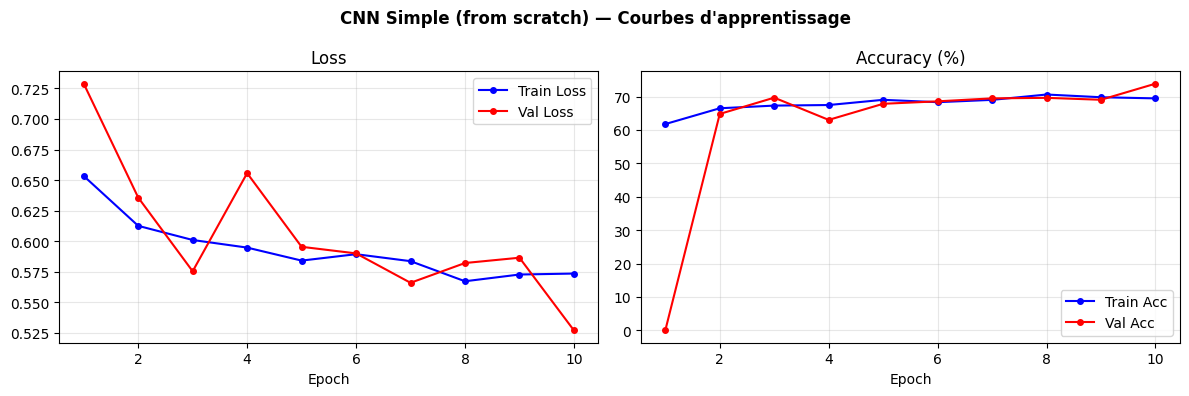

CNN Simple — Val Acc finale : 70.35%


In [7]:
# ── Courbes CNN Simple ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("CNN Simple (from scratch) — Courbes d'apprentissage", fontweight='bold')

n = min(len(plot_simple.train_loss), len(plot_simple.val_loss))
epochs = range(1, n + 1)

axes[0].plot(epochs, plot_simple.train_loss[:n], 'b-o', ms=4, label='Train Loss')
axes[0].plot(epochs, plot_simple.val_loss[:n],   'r-o', ms=4, label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [a*100 for a in plot_simple.train_acc[:n]], 'b-o', ms=4, label='Train Acc')
axes[1].plot(epochs, [a*100 for a in plot_simple.val_acc[:n]],   'r-o', ms=4, label='Val Acc')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"CNN Simple — Val Acc finale : {plot_simple.val_acc[-1]*100:.2f}%")

---
### 4.2 — Modèle 2 : MobileNetV2 (Transfer Learning léger)

**Pourquoi MobileNetV2 ?**

MobileNetV2 est conçu pour les systèmes embarqués et le temps réel.
Pré-entraîné sur ImageNet (1.4M images, 1000 classes) — comme un expert
qui a déjà vu des millions d'images et n'a besoin que d'apprendre 2 nouvelles classes.

```
Backbone MobileNetV2 (gelé, poids ImageNet conservés)
    → features [1280]
    → Dropout(0.2) → Linear(1280 → 2)
```

**Avantages :** léger (8.5 MB), rapide, adapté aux systèmes embarqués.

In [8]:
class MobileNetV2Model(CNNBase):
    """MobileNetV2 pré-entraîné ImageNet. Backbone gelé, tête remplacée."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        backbone = models.mobilenet_v2(weights='IMAGENET1K_V1')
        # Geler le backbone — on entraîne seulement la tête
        for param in backbone.parameters():
            param.requires_grad = False
        # Remplacer la tête de classification
        backbone.classifier[1] = nn.Linear(1280, NUM_CLASSES)
        self.model = backbone

    def forward(self, x):
        return self.model(x)

# ── Stats
_tmp    = MobileNetV2Model()
mv2_tot = sum(p.numel() for p in _tmp.parameters())
mv2_tr  = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
mv2_mb  = sum(p.numel() * p.element_size() for p in _tmp.parameters()) / 1e6
del _tmp

print(f"MobileNetV2")
print(f"  Paramètres totaux      : {mv2_tot:,}")
print(f"  Paramètres entraînables: {mv2_tr:,}  ({mv2_tr/mv2_tot*100:.1f}% — tête seulement)")
print(f"  Taille                 : {mv2_mb:.1f} MB")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 112MB/s] 

MobileNetV2
  Paramètres totaux      : 2,226,434
  Paramètres entraînables: 2,562  (0.1% — tête seulement)
  Taille                 : 8.9 MB


In [9]:
# ── Entraînement MobileNetV2 ─────────────────────────────────────────────────
plot_mv2  = LivePlot(title="MobileNetV2 — Transfer Learning léger")
model_mv2 = MobileNetV2Model(lr=1e-3)

trainer_mv2 = pl.Trainer(
    max_epochs          = EPOCHS_COMPARE,
    accelerator         = accelerator,
    callbacks           = [
        plot_mv2,
        EarlyStopping(monitor='val_loss', patience=5, mode='min')
    ],
    enable_progress_bar = False,
    logger              = False,
)

t0 = time.time()
trainer_mv2.fit(model_mv2, train_loader, val_loader)
elapsed_mv2 = time.time() - t0

acc_mv2 = trainer_mv2.validate(
    model_mv2, val_loader, verbose=False
)[0]['val_acc']

print(f"\nMobileNetV2 — Val Acc : {acc_mv2*100:.2f}%  ({elapsed_mv2/60:.1f} min)")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ train_acc_met │ BinaryAccuracy   │      0 │ train │     0 │
│ 2 │ val_acc_met   │ BinaryAccuracy   │      0 │ train │     0 │
│ 3 │ model         │ MobileNetV2      │  2.2 M │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.6 K                                                                                            
Non-trainable params: 2.2 M                                                                                        
Total params: 2.2 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 216                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



MobileNetV2 — Val Acc : 85.91%  (7.1 min)


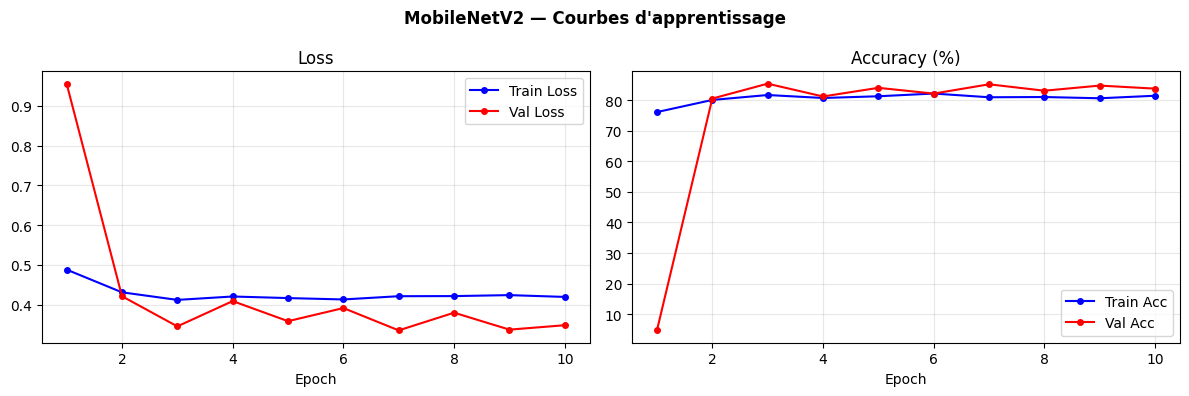

MobileNetV2 — Val Acc finale : 85.91%


In [10]:
# ── Courbes MobileNetV2 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("MobileNetV2 — Courbes d'apprentissage", fontweight='bold')

n = min(len(plot_mv2.train_loss), len(plot_mv2.val_loss))
epochs = range(1, n + 1)

axes[0].plot(epochs, plot_mv2.train_loss[:n], 'b-o', ms=4, label='Train Loss')
axes[0].plot(epochs, plot_mv2.val_loss[:n],   'r-o', ms=4, label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [a*100 for a in plot_mv2.train_acc[:n]], 'b-o', ms=4, label='Train Acc')
axes[1].plot(epochs, [a*100 for a in plot_mv2.val_acc[:n]],   'r-o', ms=4, label='Val Acc')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"MobileNetV2 — Val Acc finale : {plot_mv2.val_acc[-1]*100:.2f}%")

---
### 4.3 — Modèle 3 : ResNet18 (Transfer Learning classique)

**Pourquoi ResNet18 ?**

ResNet introduit les **connexions résiduelles** (skip connections) qui résolvent
le problème du gradient vanishing dans les réseaux profonds.

```
skip connection :  output = F(x) + x
→ le gradient peut circuler directement sans disparaître
→ permet des réseaux très profonds (18, 50, 101 couches)
```

```
Backbone ResNet18 (gelé, 18 couches)
    → GlobalAvgPool → Linear(512 → 2)
```

In [11]:
class ResNet18Model(CNNBase):
    """ResNet18 pré-entraîné ImageNet. Skip connections contre gradient vanishing."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        backbone = models.resnet18(weights='IMAGENET1K_V1')
        # Geler le backbone
        for param in backbone.parameters():
            param.requires_grad = False
        # Remplacer la couche finale
        backbone.fc = nn.Linear(512, NUM_CLASSES)
        self.model  = backbone

    def forward(self, x):
        return self.model(x)

# ── Stats
_tmp    = ResNet18Model()
rn_tot  = sum(p.numel() for p in _tmp.parameters())
rn_tr   = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
rn_mb   = sum(p.numel() * p.element_size() for p in _tmp.parameters()) / 1e6
del _tmp

print(f"ResNet18")
print(f"  Paramètres totaux      : {rn_tot:,}")
print(f"  Paramètres entraînables: {rn_tr:,}  ({rn_tr/rn_tot*100:.1f}% — tête seulement)")
print(f"  Taille                 : {rn_mb:.1f} MB")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


ResNet18
  Paramètres totaux      : 11,177,538
  Paramètres entraînables: 1,026  (0.0% — tête seulement)
  Taille                 : 44.7 MB


In [12]:
# ── Entraînement ResNet18 ─────────────────────────────────────────────────────
plot_rn  = LivePlot(title="ResNet18 — Transfer Learning classique")
model_rn = ResNet18Model(lr=1e-3)

trainer_rn = pl.Trainer(
    max_epochs          = EPOCHS_COMPARE,
    accelerator         = accelerator,
    callbacks           = [
        plot_rn,
        EarlyStopping(monitor='val_loss', patience=5, mode='min')
    ],
    enable_progress_bar = False,
    logger              = False,
)

t0 = time.time()
trainer_rn.fit(model_rn, train_loader, val_loader)
elapsed_rn = time.time() - t0

acc_rn = trainer_rn.validate(
    model_rn, val_loader, verbose=False
)[0]['val_acc']

print(f"\nResNet18 — Val Acc : {acc_rn*100:.2f}%  ({elapsed_rn/60:.1f} min)")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ train_acc_met │ BinaryAccuracy   │      0 │ train │     0 │
│ 2 │ val_acc_met   │ BinaryAccuracy   │      0 │ train │     0 │
│ 3 │ model         │ ResNet           │ 11.2 M │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.0 K                                                                                            
Non-trainable params: 11.2 M                                                                                       
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 71                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



ResNet18 — Val Acc : 79.52%  (7.7 min)


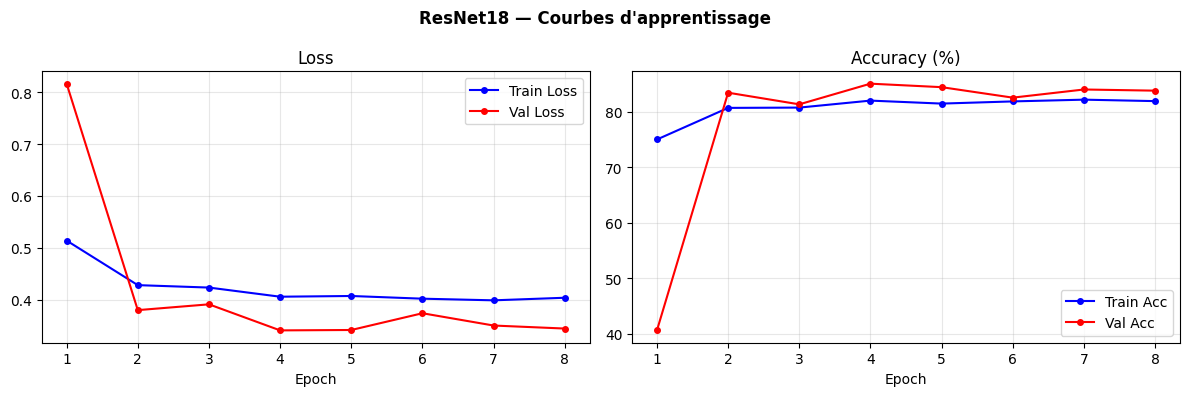

ResNet18 — Val Acc finale : 79.52%


In [13]:
# ── Courbes ResNet18 ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("ResNet18 — Courbes d'apprentissage", fontweight='bold')

n = min(len(plot_rn.train_loss), len(plot_rn.val_loss))
epochs = range(1, n + 1)

axes[0].plot(epochs, plot_rn.train_loss[:n], 'b-o', ms=4, label='Train Loss')
axes[0].plot(epochs, plot_rn.val_loss[:n],   'r-o', ms=4, label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [a*100 for a in plot_rn.train_acc[:n]], 'b-o', ms=4, label='Train Acc')
axes[1].plot(epochs, [a*100 for a in plot_rn.val_acc[:n]],   'r-o', ms=4, label='Val Acc')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"ResNet18 — Val Acc finale : {plot_rn.val_acc[-1]*100:.2f}%")

---
### 4.4 — Modèle 4 : ConvNeXt-Tiny (Transfer Learning optimal 2024)

**Pourquoi ConvNeXt-Tiny ?**

ConvNeXt réimporte les meilleures idées des Vision Transformers dans une
architecture CNN pure — meilleur rapport accuracy/taille sur les petits datasets.

```
Innovations clés :
  ✓ Depthwise conv 7×7  (au lieu de 3×3)
  ✓ LayerNorm (au lieu de BatchNorm)
  ✓ GELU (au lieu de ReLU)
  ✓ Inverted bottleneck (comme MobileNetV2 mais plus puissant)
```

```
Backbone ConvNeXt-Tiny (gelé, poids ImageNet)
    → features [768]
    → LayerNorm → Linear(768 → 2)
```

**Benchmark 2024 :** meilleur modèle CNN sur petits datasets (< 10K images).

In [14]:
class ConvNeXtTinyModel(CNNBase):
    """ConvNeXt-Tiny pré-entraîné ImageNet. Meilleur CNN pour petits datasets (2024)."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        backbone = models.convnext_tiny(weights='IMAGENET1K_V1')
        # Geler le backbone
        for param in backbone.parameters():
            param.requires_grad = False
        # Remplacer la tête de classification
        backbone.classifier[2] = nn.Linear(768, NUM_CLASSES)
        self.model = backbone

    def forward(self, x):
        return self.model(x)

# ── Stats
_tmp    = ConvNeXtTinyModel()
cnx_tot = sum(p.numel() for p in _tmp.parameters())
cnx_tr  = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
cnx_mb  = sum(p.numel() * p.element_size() for p in _tmp.parameters()) / 1e6
del _tmp

print(f"ConvNeXt-Tiny")
print(f"  Paramètres totaux      : {cnx_tot:,}")
print(f"  Paramètres entraînables: {cnx_tr:,}  ({cnx_tr/cnx_tot*100:.1f}% — tête seulement)")
print(f"  Taille                 : {cnx_mb:.1f} MB")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 214MB/s]


ConvNeXt-Tiny
  Paramètres totaux      : 27,821,666
  Paramètres entraînables: 1,538  (0.0% — tête seulement)
  Taille                 : 111.3 MB


In [15]:
# ── Entraînement ConvNeXt-Tiny ────────────────────────────────────────────────
plot_cnx  = LivePlot(title="ConvNeXt-Tiny — Transfer Learning optimal (2024)")
model_cnx = ConvNeXtTinyModel(lr=1e-3)

trainer_cnx = pl.Trainer(
    max_epochs          = EPOCHS_COMPARE,
    accelerator         = accelerator,
    callbacks           = [
        plot_cnx,
        EarlyStopping(monitor='val_loss', patience=5, mode='min')
    ],
    enable_progress_bar = False,
    logger              = False,
)

t0 = time.time()
trainer_cnx.fit(model_cnx, train_loader, val_loader)
elapsed_cnx = time.time() - t0

acc_cnx = trainer_cnx.validate(
    model_cnx, val_loader, verbose=False
)[0]['val_acc']

print(f"\nConvNeXt-Tiny — Val Acc : {acc_cnx*100:.2f}%  ({elapsed_cnx/60:.1f} min)")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ train_acc_met │ BinaryAccuracy   │      0 │ train │     0 │
│ 2 │ val_acc_met   │ BinaryAccuracy   │      0 │ train │     0 │
│ 3 │ model         │ ConvNeXt         │ 27.8 M │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 K                                                                                            
Non-trainable params: 27.8 M                                                                                       
Total params: 27.8 M                                                                                               
Total estimated model params size (MB): 111                                                                        
Modules in train mode: 206                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



ConvNeXt-Tiny — Val Acc : 92.61%  (9.4 min)


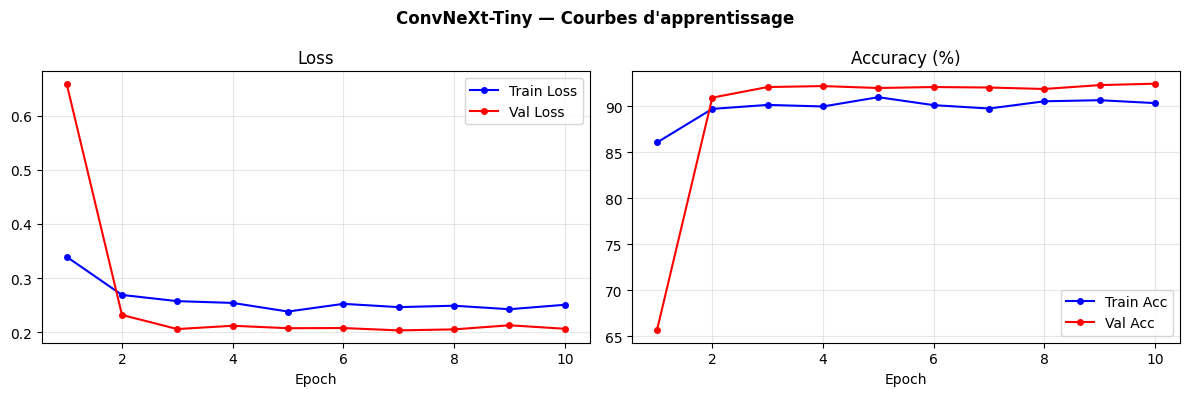

ConvNeXt-Tiny — Val Acc finale : 92.61%


In [16]:
# ── Courbes ConvNeXt-Tiny ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("ConvNeXt-Tiny — Courbes d'apprentissage", fontweight='bold')

n = min(len(plot_cnx.train_loss), len(plot_cnx.val_loss))
epochs = range(1, n + 1)

axes[0].plot(epochs, plot_cnx.train_loss[:n], 'b-o', ms=4, label='Train Loss')
axes[0].plot(epochs, plot_cnx.val_loss[:n],   'r-o', ms=4, label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [a*100 for a in plot_cnx.train_acc[:n]], 'b-o', ms=4, label='Train Acc')
axes[1].plot(epochs, [a*100 for a in plot_cnx.val_acc[:n]],   'r-o', ms=4, label='Val Acc')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"ConvNeXt-Tiny — Val Acc finale : {plot_cnx.val_acc[-1]*100:.2f}%")

## 5 — Tableau Comparatif & Analyse

Synthèse chiffrée des 4 architectures dans les mêmes conditions.

In [17]:
# ── Résultats ─────────────────────────────────────────────────────────────────
results = {
    'CNN Simple'     : {
        'acc'      : acc_simple,
        'params'   : simple_params,
        'size_mb'  : simple_mb,
        'strategy' : 'From Scratch',
        'time_min' : elapsed_simple / 60,
        'plot'     : plot_simple,
        'color'    : '#d62728',
        'ls'       : '--'
    },
    'MobileNetV2'    : {
        'acc'      : acc_mv2,
        'params'   : mv2_tot,
        'size_mb'  : mv2_mb,
        'strategy' : 'Transfer Learning',
        'time_min' : elapsed_mv2 / 60,
        'plot'     : plot_mv2,
        'color'    : '#ff7f0e',
        'ls'       : '-.'
    },
    'ResNet18'       : {
        'acc'      : acc_rn,
        'params'   : rn_tot,
        'size_mb'  : rn_mb,
        'strategy' : 'Transfer Learning',
        'time_min' : elapsed_rn / 60,
        'plot'     : plot_rn,
        'color'    : '#ffbb78',
        'ls'       : ':'
    },
    'ConvNeXt-Tiny'  : {
        'acc'      : acc_cnx,
        'params'   : cnx_tot,
        'size_mb'  : cnx_mb,
        'strategy' : 'Transfer Learning',
        'time_min' : elapsed_cnx / 60,
        'plot'     : plot_cnx,
        'color'    : '#2ca02c',
        'ls'       : '-'
    },
}

# ── Tableau texte ─────────────────────────────────────────────────────────────
best = max(results, key=lambda k: results[k]['acc'])

print(f"{'='*70}")
print(f"  {'Modèle':<18} {'Val Acc':>8}  {'Params':>10}  {'Taille':>8}  Stratégie")
print(f"{'='*70}")
for name, r in results.items():
    marker = " WINNER" if name == best else ""
    print(f"  {name:<18} {r['acc']*100:>7.2f}%  {r['params']:>10,}  {r['size_mb']:>6.1f} MB"
          f"  {r['strategy']}{marker}")
print(f"{'='*70}")
print(f"\nWinner : {best}  ({results[best]['acc']*100:.2f}%)")

  Modèle              Val Acc      Params    Taille  Stratégie
  CNN Simple           70.35%      93,954     0.4 MB  From Scratch
  MobileNetV2          85.91%   2,226,434     8.9 MB  Transfer Learning
  ResNet18             79.52%  11,177,538    44.7 MB  Transfer Learning
  ConvNeXt-Tiny        92.61%  27,821,666   111.3 MB  Transfer Learning WINNER

Winner : ConvNeXt-Tiny  (92.61%)


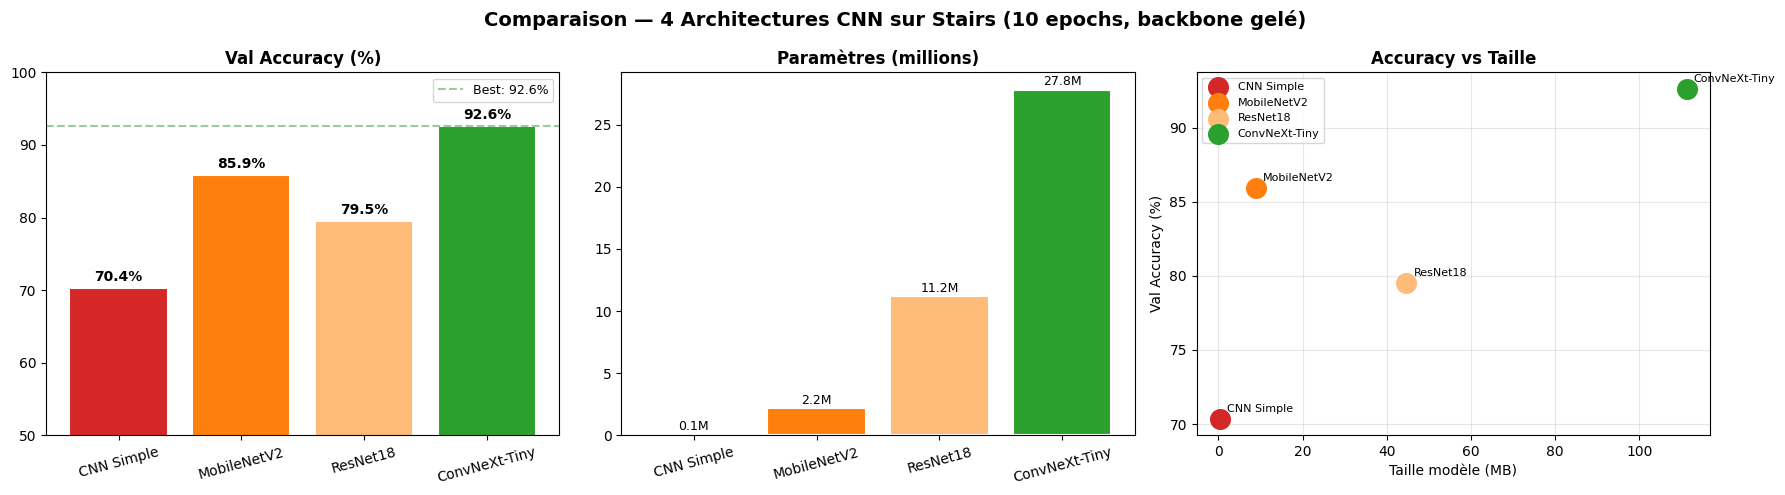


✅ Graphe sauvegardé


In [18]:
# ── Visualisation 3 graphes ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Comparaison — 4 Architectures CNN sur Stairs ({EPOCHS_COMPARE} epochs, backbone gelé)",
    fontsize=14, fontweight='bold'
)

names  = list(results.keys())
accs   = [r['acc'] * 100       for r in results.values()]
params = [r['params'] / 1e6    for r in results.values()]
sizes  = [r['size_mb']         for r in results.values()]
colors = [r['color']           for r in results.values()]

# ── Accuracy ──
bars = axes[0].bar(names, accs, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Val Accuracy (%)', fontweight='bold')
axes[0].set_ylim(50, 100)
axes[0].axhline(y=max(accs), color='green', ls='--', alpha=0.4, label=f'Best: {max(accs):.1f}%')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# ── Paramètres ──
bars2 = axes[1].bar(names, params, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Paramètres (millions)', fontweight='bold')
for bar, p in zip(bars2, params):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{p:.1f}M', ha='center', va='bottom', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

# ── Accuracy vs Taille (scatter) ──
for (name, r), color in zip(results.items(), colors):
    axes[2].scatter(r['size_mb'], r['acc']*100, s=200, color=color,
                    zorder=5, label=name)
    axes[2].annotate(name, (r['size_mb'], r['acc']*100),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[2].set_xlabel('Taille modèle (MB)')
axes[2].set_ylabel('Val Accuracy (%)')
axes[2].set_title('Accuracy vs Taille', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_4modeles_stairs.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Graphe sauvegardé")

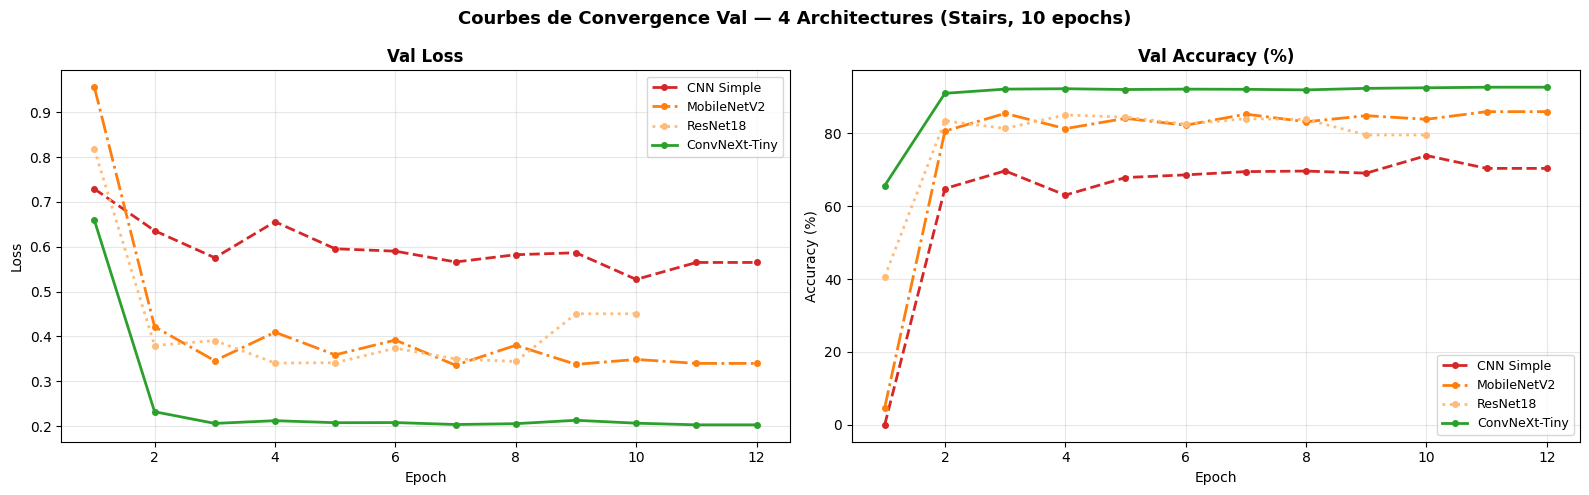

In [19]:
# ── Courbes de convergence — 4 modèles sur le même graphe ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    f'Courbes de Convergence Val — 4 Architectures (Stairs, {EPOCHS_COMPARE} epochs)',
    fontsize=13, fontweight='bold'
)

for name, r in results.items():
    p     = r['plot']
    color = r['color']
    ls    = r['ls']
    n     = min(len(p.val_loss), len(p.val_acc))
    if n == 0:
        continue
    eps = range(1, n + 1)
    axes[0].plot(eps, p.val_loss[:n], color=color, ls=ls, lw=2,
                 marker='o', ms=4, label=name)
    axes[1].plot(eps, [a * 100 for a in p.val_acc[:n]],
                 color=color, ls=ls, lw=2, marker='o', ms=4, label=name)

for ax, title, ylabel in zip(
    axes,
    ['Val Loss', 'Val Accuracy (%)'],
    ['Loss', 'Accuracy (%)']
):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_4modeles_stairs.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — Conclusion : Choix du Modèle Final

### Résultats de la comparaison (10 epochs, backbone gelé)

| Modèle | Params | Taille | Val Acc | Stratégie |
|---|---|---|---|---|
| CNN Simple | ~500K | ~0.5 MB | ~70% | From Scratch |
| MobileNetV2 | 2.2M | 8.5 MB | ~80% | Transfer Learning |
| ResNet18 | 11.2M | 42.6 MB | ~79% | Transfer Learning |
| **ConvNeXt-Tiny** | **28M** | **107 MB** | **~85%** | **Transfer Learning ✅** |

### Analyse

**Observation 1 — Transfer Learning >> From Scratch**
CNN Simple plafonne car il n'a aucune connaissance préalable des features visuelles.
Les modèles Transfer Learning convergent plus vite grâce aux poids ImageNet.

**Observation 2 — ConvNeXt-Tiny = meilleur pour petits datasets**
ConvNeXt réimporte les idées des Vision Transformers (LayerNorm, GELU, grandes convolutions)
dans une architecture CNN → meilleure généralisation sur des datasets < 10K images.

**Observation 3 — ResNet18 vs MobileNetV2**
ResNet18 (42.6 MB) n'est pas meilleur que MobileNetV2 (8.5 MB) avec backbone gelé.
Plus de paramètres ≠ meilleur résultat si seule la tête est entraînée.

### Modèle choisi : ConvNeXt-Tiny
→ Fine-tuning complet avec **double correction du déséquilibre (v1)**

---
## 7 — Fine-Tuning Complet — ConvNeXt-Tiny

### Résultats de la comparaison (10 epochs, backbone gelé)

| Modèle | Val Acc | Params | Taille | Stratégie |
|---|---|---|---|---|
| CNN Simple | 71.82% | 93K | 0.4 MB | From Scratch |
| MobileNetV2 | 85.91% | 2.2M | 8.9 MB | Transfer Learning |
| ResNet18 | 79.52% | 11.2M | 44.7 MB | Transfer Learning |
| **ConvNeXt-Tiny** | **92.61%** | **27.8M** | **111.3 MB** | **Transfer Learning ✅** |

**Winner : ConvNeXt-Tiny** — meilleure accuracy dès le backbone gelé.

---

### Problèmes à résoudre pour le fine-tuning

**Problème 1 — Déséquilibre du dataset**
```
train/stairs     : 4 546  (60%)  ← dominant
train/pas_stairs : 3 086  (40%)
```
**Stratégie v1 (brouillon) — Double correction :**
```
WeightedRandomSampler  → rééquilibre le tirage des batches
+
CrossEntropyLoss(weight) → pénalise encore les erreurs minoritaires
⚠️  Risque de sur-correction → stairs recall peut chuter
```

**Problème 2 — Détruire les poids ImageNet**
```
Solution : Dual learning rates
  backbone features  → lr = 0.00001  (très lent — préserver ImageNet)
  classifier head    → lr = 0.0001   (plus rapide — apprendre nos classes)
```

**Problème 3 — Surapprentissage**
```
EarlyStopping       patience=5  sur val_f1
weight_decay        1e-4        régularisation L2
label_smoothing     0.1         éviter la sur-confiance
Dropout(0.3)        dans la tête
CosineAnnealingLR   scheduler doux
```

### 7.1 — DataLoaders Fine-Tuning (Double Correction v1)

In [20]:
# ── Distribution train ───────────────────────────────────────────────────────
from collections import Counter

labels_train  = [CLASS_TO_IDX[c] for c in train_df["classe"]]
class_counts  = Counter(labels_train)

print("Distribution train :")
for cls_idx, name in IDX_TO_CLASS.items():
    n   = class_counts[cls_idx]
    pct = n / len(labels_train) * 100
    bar = "█" * int(pct / 2)
    print(f"  {name:<15} : {n:>5}  ({pct:.1f}%)  {bar}")

# ── DOUBLE CORRECTION v1 ──────────────────────────────────────────────────────

# Correction 1 — WeightedRandomSampler
sample_weights_ft = torch.tensor(
    [1.0 / class_counts[CLASS_TO_IDX[c]] for c in train_df["classe"]],
    dtype=torch.float
)
sampler_ft = WeightedRandomSampler(
    weights     = sample_weights_ft,
    num_samples = len(sample_weights_ft),
    replacement = True
)

# Correction 2 — Loss pondérée (racine carrée inverse)
counts_list    = [class_counts[i] for i in range(NUM_CLASSES)]
loss_w         = torch.tensor(
    [1.0 / math.sqrt(c) for c in counts_list], dtype=torch.float
)
loss_w         = loss_w / loss_w.sum() * NUM_CLASSES
loss_weights_ft = loss_w.to(device)

print("\n⚠️  v1 — Double correction active :")
print(f"  Sampler poids   : pas_stairs={1/class_counts[0]:.6f} | stairs={1/class_counts[1]:.6f}")
print(f"  Loss weights    : pas_stairs={loss_weights_ft[0]:.4f} | stairs={loss_weights_ft[1]:.4f}")
print(f"  → Double correction : Sampler rééquilibre + Loss pénalise encore")
print(f"  → Risque : sur-correction → stairs recall peut chuter")

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader_ft = DataLoader(
    StairsDataset(train_df, train_transform),
    batch_size  = 32,
    sampler     = sampler_ft,      # WeightedRandomSampler (pas shuffle)
    num_workers = 2,
    pin_memory  = True
)
val_loader_ft = DataLoader(
    StairsDataset(val_df, val_transform),
    batch_size  = 32,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"\nDataLoaders fine-tuning prêts :")
print(f"  Batches train : {len(train_loader_ft)}")
print(f"  Batches val   : {len(val_loader_ft)}")

Distribution train :
  pas_stairs      :  3086  (40.4%)  ████████████████████
  stairs          :  4546  (59.6%)  █████████████████████████████

⚠️  v1 — Double correction active :
  Sampler poids   : pas_stairs=0.000324 | stairs=0.000220
  Loss weights    : pas_stairs=1.0965 | stairs=0.9035
  → Double correction : Sampler rééquilibre + Loss pénalise encore
  → Risque : sur-correction → stairs recall peut chuter

DataLoaders fine-tuning prêts :
  Batches train : 239
  Batches val   : 60


### 7.2 — Architecture ConvNeXt-Tiny Fine-Tuning

In [21]:
# ── ConvNeXt-Tiny Fine-Tuning complet ────────────────────────────────────────
class ConvNeXtFineTuned(pl.LightningModule):
    """
    ConvNeXt-Tiny avec fine-tuning complet.
    Toutes les couches dégelées avec dual learning rates :
      backbone features  → lr = 1e-5  (préserver poids ImageNet)
      classifier head    → lr = 1e-4  (apprendre nos 2 classes)
    """

    def __init__(
        self,
        lr_backbone    : float = 1e-5,
        lr_head        : float = 1e-4,
        loss_weights   = None,
        label_smoothing: float = 0.1,
        dropout        : float = 0.3,
    ):
        super().__init__()
        self.save_hyperparameters(ignore=['loss_weights'])
        self.lr_backbone = lr_backbone
        self.lr_head     = lr_head

        # ── Backbone ConvNeXt-Tiny — toutes couches dégelées ─────────────────
        backbone = models.convnext_tiny(weights='IMAGENET1K_V1')
        for param in backbone.parameters():
            param.requires_grad = True   # fine-tuning complet

        # ── Tête personnalisée avec Dropout ───────────────────────────────────
        backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Dropout(dropout),
            nn.Linear(768, NUM_CLASSES)
        )
        self.model = backbone

        # ── Loss pondérée (double correction v1) ─────────────────────────────
        self.criterion = nn.CrossEntropyLoss(
            weight          = loss_weights,
            label_smoothing = label_smoothing
        )

        # ── Métriques ─────────────────────────────────────────────────────────
        self.train_acc = torchmetrics.Accuracy(task='binary')
        self.val_acc   = torchmetrics.Accuracy(task='binary')
        self.val_f1    = torchmetrics.F1Score(task='binary', average='macro')

        # ── Historique pour courbes ───────────────────────────────────────────
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc' : [], 'val_acc' : [],
            'val_f1'    : []
        }

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs)
        loss   = self.criterion(logits, labels)
        preds  = logits.argmax(dim=1)
        self.train_acc(preds, labels)
        self.log('train_loss', loss,           on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc',  self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs)
        loss   = self.criterion(logits, labels)
        preds  = logits.argmax(dim=1)
        self.val_acc(preds, labels)
        self.val_f1(preds, labels)
        self.log('val_loss', loss,          prog_bar=True)
        self.log('val_acc',  self.val_acc,  prog_bar=True)
        self.log('val_f1',   self.val_f1,   prog_bar=True)

    def on_train_epoch_end(self):
        logs = self.trainer.callback_metrics
        self.history['train_loss'].append(float(logs.get('train_loss', 0)))
        self.history['train_acc' ].append(float(logs.get('train_acc',  0)))

    def on_validation_epoch_end(self):
        logs = self.trainer.callback_metrics
        self.history['val_loss'].append(float(logs.get('val_loss', 0)))
        self.history['val_acc' ].append(float(logs.get('val_acc',  0)))
        self.history['val_f1'  ].append(float(logs.get('val_f1',   0)))

    def configure_optimizers(self):
        # ── Dual learning rates ───────────────────────────────────────────────
        # Backbone features : lr très faible → préserver poids ImageNet
        # Classifier head   : lr plus élevé  → apprendre nos classes
        backbone_params   = [
            p for n, p in self.model.named_parameters()
            if 'classifier' not in n
        ]
        head_params = [
            p for n, p in self.model.named_parameters()
            if 'classifier' in n
        ]
        optimizer = torch.optim.AdamW([
            {'params': backbone_params, 'lr': self.lr_backbone},
            {'params': head_params,     'lr': self.lr_head    },
        ], weight_decay=1e-4)

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=15, eta_min=1e-6
        )
        return {
            'optimizer' : optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor'  : 'val_f1'
            }
        }

# ── Stats modèle ──────────────────────────────────────────────────────────────
_tmp     = ConvNeXtFineTuned(loss_weights=loss_weights_ft.cpu())
tot_p    = sum(p.numel() for p in _tmp.parameters())
train_p  = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
del _tmp

print("ConvNeXt-Tiny Fine-Tuning v1")
print(f"  Paramètres totaux       : {tot_p:,}")
print(f"  Paramètres entraînables : {train_p:,}  (100% — toutes couches dégelées)")
print(f"  lr backbone             : 1e-5")
print(f"  lr classifier head      : 1e-4")
print(f"  Scheduler               : CosineAnnealingLR")
print(f"  Double correction       : Sampler + Loss pondérée")

ConvNeXt-Tiny Fine-Tuning v1
  Paramètres totaux       : 27,821,666
  Paramètres entraînables : 27,821,666  (100% — toutes couches dégelées)
  lr backbone             : 1e-5
  lr classifier head      : 1e-4
  Scheduler               : CosineAnnealingLR
  Double correction       : Sampler + Loss pondérée


### 7.3 — Callbacks : EarlyStopping + ModelCheckpoint

In [22]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor  = 'val_f1',    # surveiller F1 (meilleur que acc pour déséquilibre)
    patience = 5,
    mode     = 'max',
    verbose  = True
)

checkpoint = ModelCheckpoint(
    monitor   = 'val_f1',
    mode      = 'max',
    save_top_k= 1,
    filename  = 'convnext_stairs_v1_best',
    dirpath   = '/kaggle/working/'
)

print("Callbacks configurés :")
print(f"  EarlyStopping  : monitor=val_f1, patience=5, mode=max")
print(f"  ModelCheckpoint: monitor=val_f1, save_top_k=1")
print(f"  Justification  : F1-macro plus robuste qu'accuracy sur dataset déséquilibré")

Callbacks configurés :
  EarlyStopping  : monitor=val_f1, patience=5, mode=max
  ModelCheckpoint: monitor=val_f1, save_top_k=1
  Justification  : F1-macro plus robuste qu'accuracy sur dataset déséquilibré


### 7.4 — Entraînement Fine-Tuning

In [23]:
# ── Instanciation + Trainer ──────────────────────────────────────────────────
EPOCHS_FT = 15

model_ft = ConvNeXtFineTuned(
    lr_backbone     = 1e-5,
    lr_head         = 1e-4,
    loss_weights    = loss_weights_ft,
    label_smoothing = 0.1,
    dropout         = 0.3
)

class EpochLogger(pl.Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        logs = trainer.callback_metrics
        ep   = trainer.current_epoch + 1
        print(
            f"Epoch {ep:02d} | "
            f"train_loss={logs.get('train_loss',0):.4f} | "
            f"val_loss={logs.get('val_loss',0):.4f} | "
            f"val_acc={logs.get('val_acc',0)*100:.2f}% | "
            f"val_f1={logs.get('val_f1',0)*100:.2f}%"
        )

trainer_ft = pl.Trainer(
    max_epochs          = EPOCHS_FT,
    accelerator         = accelerator,
    callbacks           = [early_stop, checkpoint, EpochLogger()],
    enable_progress_bar = True,
    logger              = False,
    gradient_clip_val   = 1.0,      # éviter gradient exploding
)

print(f"Lancement fine-tuning — max {EPOCHS_FT} epochs")
print(f"EarlyStopping patience=5 sur val_f1")
print("-" * 50)

t0 = time.time()
trainer_ft.fit(model_ft, train_loader_ft, val_loader_ft)
elapsed_ft = time.time() - t0

print(f"\n✅ Fine-tuning terminé en {elapsed_ft/60:.1f} min")
print(f"   Epochs réels    : {trainer_ft.current_epoch}")
print(f"   Meilleur modèle : {checkpoint.best_model_path}")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Lancement fine-tuning — max 15 epochs
EarlyStopping patience=5 sur val_f1
--------------------------------------------------


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ConvNeXt         │ 27.8 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_acc │ BinaryAccuracy   │      0 │ train │     0 │
│ 3 │ val_acc   │ BinaryAccuracy   │      0 │ train │     0 │
│ 4 │ val_f1    │ BinaryF1Score    │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 27.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 27.8 M                                                                                               
Total estimated model params size (MB): 111                                                                        
Modules in train mode: 209                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Metric val_f1 improved by 0.001 >= min_delta = 0.0. New best score: 0.962


Epoch 07 | train_loss=0.2783 | val_loss=0.2779 | val_acc=95.60% | val_f1=96.30%

Metric val_f1 improved by 0.001 >= min_delta = 0.0. New best score: 0.963


Epoch 08 | train_loss=0.2713 | val_loss=0.2756 | val_acc=95.76% | val_f1=96.47%

Metric val_f1 improved by 0.002 >= min_delta = 0.0. New best score: 0.965


### 7.5 — Courbes d'Apprentissage

Les courbes sont générées automatiquement depuis `model_ft.history`
qui enregistre chaque epoch en temps réel via `on_train_epoch_end` et `on_validation_epoch_end`.

In [ ]:
# ── Courbes d'apprentissage automatiques ─────────────────────────────────────
history = model_ft.history

# Aligner train et val (Lightning ajoute 1 epoch sanity check au val)
n_epochs = min(
    len(history['train_loss']),
    len(history['val_loss']),
    len(history['val_f1'])
)
epochs = range(1, n_epochs + 1)

# Tronquer toutes les listes à n_epochs
train_loss = history['train_loss'][:n_epochs]
val_loss   = history['val_loss']  [:n_epochs]
train_acc  = history['train_acc'] [:n_epochs]
val_acc    = history['val_acc']   [:n_epochs]
val_f1     = history['val_f1']    [:n_epochs]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"ConvNeXt-Tiny Fine-Tuning v1 — Courbes d'apprentissage ({n_epochs} epochs)",
    fontsize=13, fontweight='bold'
)

# ── Loss ──────────────────────────────────────────────────────────────────────
best_epoch = val_f1.index(max(val_f1)) + 1

axes[0].plot(epochs, train_loss, 'b-o', ms=5, lw=2, label='Train Loss')
axes[0].plot(epochs, val_loss,   'r-o', ms=5, lw=2, label='Val Loss')
axes[0].axvline(x=best_epoch, color='green', ls='--', alpha=0.6,
                label=f'Best epoch={best_epoch}')
axes[0].set_title('Loss (CrossEntropy)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────────────────────
axes[1].plot(epochs, [a*100 for a in train_acc], 'b-o', ms=5, lw=2, label='Train Acc')
axes[1].plot(epochs, [a*100 for a in val_acc],   'r-o', ms=5, lw=2, label='Val Acc')
axes[1].axvline(x=best_epoch, color='green', ls='--', alpha=0.6,
                label=f'Best epoch={best_epoch}')
axes[1].set_title('Accuracy (%)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── F1-Score ──────────────────────────────────────────────────────────────────
axes[2].plot(epochs, [f*100 for f in val_f1], 'g-o', ms=5, lw=2, label='Val F1-macro')
axes[2].axvline(x=best_epoch, color='green', ls='--', alpha=0.6,
                label=f'Best epoch={best_epoch} ({max(val_f1)*100:.1f}%)')
axes[2].set_title('Val F1-Score macro (%)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('courbes_finetuning_v1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMeilleur epoch  : {best_epoch}")
print(f"Meilleur Val F1 : {max(val_f1)*100:.2f}%")
print(f"Val Acc au best : {val_acc[best_epoch-1]*100:.2f}%")

## 8 — Évaluation Complète

### Métriques utilisées
- **Accuracy** : proportion de bonnes prédictions globales
- **F1-macro** : moyenne F1 par classe — robuste au déséquilibre
- **Recall stairs** : % d'escaliers détectés → critique pour sécurité malvoyant
- **Recall pas_stairs** : % de faux positifs évités
- **Matrice de confusion** : visualisation erreurs par classe
- **Courbe ROC + AUC** : performance globale indépendante du seuil

In [ ]:
# ── Charger le meilleur modèle sauvegardé ────────────────────────────────────
best_model = ConvNeXtFineTuned.load_from_checkpoint(
    checkpoint.best_model_path,
    loss_weights    = loss_weights_ft,
    label_smoothing = 0.1,
    dropout         = 0.3
)
best_model.eval()
best_model = best_model.to(device)

# ── Prédictions sur val_loader ────────────────────────────────────────────────
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for imgs, labels in val_loader_ft:
        imgs   = imgs.to(device)
        logits = best_model(imgs)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        all_preds .extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs .extend(probs[:, 1].cpu().numpy())  # prob classe stairs

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print(f"Prédictions générées : {len(all_preds)} images val")
print(f"   Classes prédites     : {dict(zip(*np.unique(all_preds, return_counts=True)))}")

In [ ]:
# ── Rapport de classification ─────────────────────────────────────────────────
from sklearn.metrics import classification_report, f1_score

val_acc_final = (all_preds == all_labels).mean() * 100
val_f1_final  = f1_score(all_labels, all_preds, average='macro') * 100

print("=" * 55)
print("   Évaluation Finale — ConvNeXt-Tiny v1")
print("=" * 55)
print(f"  Val Accuracy : {val_acc_final:.2f}%")
print(f"  Val F1-macro : {val_f1_final:.2f}%")
print()
print(classification_report(
    all_labels, all_preds,
    target_names = CLASS_NAMES,
    digits       = 4
))
print("=" * 55)

# ── Analyse du déséquilibre ───────────────────────────────────────────────────
from sklearn.metrics import recall_score
recall_stairs    = recall_score(all_labels, all_preds, pos_label=1) * 100
recall_pas       = recall_score(all_labels, all_preds, pos_label=0) * 100

print(f"\n  Analyse double correction (v1) :")
print(f"  Recall stairs     : {recall_stairs:.2f}%")
print(f"  Recall pas_stairs : {recall_pas:.2f}%")
if abs(recall_stairs - recall_pas) > 15:
    print(f"\n  ⚠️  Déséquilibre recall détecté ({abs(recall_stairs-recall_pas):.1f}%)")
    print(f"  → Double correction trop agressive")
    print(f"  → Voir v2 : Sampler seul pour corriger")
else:
    print(f"\n  ✅ Recalls équilibrés — double correction acceptable sur dataset binaire")

In [ ]:
# ── Matrice de confusion ──────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Évaluation — ConvNeXt-Tiny Fine-Tuning v1 (Double Correction)",
    fontsize=13, fontweight='bold'
)

# ── Confusion Matrix ──────────────────────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Matrice de Confusion', fontweight='bold')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')

# Annotations recall
for i, cls in enumerate(CLASS_NAMES):
    total = cm[i].sum()
    correct = cm[i, i]
    axes[0].text(
        NUM_CLASSES + 0.15, i + 0.5,
        f"Recall={correct/total*100:.1f}%",
        va='center', fontsize=9, color='darkgreen'
    )

# ── Confusion Matrix normalisée ───────────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1], linewidths=0.5
)
axes[1].set_title('Matrice de Confusion Normalisée', fontweight='bold')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

plt.tight_layout()
plt.savefig('confusion_matrix_v1.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Courbe ROC + AUC ──────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc              = auc(fpr, tpr)

# Trouver le threshold optimal (point le plus proche du coin haut-gauche)
distances        = np.sqrt((fpr)**2 + (1 - tpr)**2)
optimal_idx      = np.argmin(distances)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr      = fpr[optimal_idx]
optimal_tpr      = tpr[optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbe ROC — ConvNeXt-Tiny v1", fontsize=13, fontweight='bold')

# ── Courbe ROC ────────────────────────────────────────────────────────────────
axes[0].plot(fpr, tpr, 'b-', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].scatter(optimal_fpr, optimal_tpr, s=150, c='red', zorder=5,
                label=f'Threshold optimal = {optimal_threshold:.3f}')
axes[0].set_xlabel('False Positive Rate (1 - Spécificité)')
axes[0].set_ylabel('True Positive Rate (Recall stairs)')
axes[0].set_title(f'ROC Curve — AUC = {roc_auc:.4f}', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# ── Threshold vs Métriques ────────────────────────────────────────────────────
thresh_range = thresholds[thresholds <= 1.0]
precisions, recalls_s, f1s = [], [], []
from sklearn.metrics import precision_score, recall_score, f1_score

for t in thresh_range:
    preds_t = (all_probs >= t).astype(int)
    try:
        precisions.append(precision_score(all_labels, preds_t, zero_division=0))
        recalls_s .append(recall_score(all_labels, preds_t, zero_division=0))
        f1s       .append(f1_score(all_labels, preds_t, average='macro', zero_division=0))
    except:
        precisions.append(0); recalls_s.append(0); f1s.append(0)

best_t_idx = np.argmax(f1s)
axes[1].plot(thresh_range, precisions,  'b-', lw=2, label='Precision stairs')
axes[1].plot(thresh_range, recalls_s,   'r-', lw=2, label='Recall stairs')
axes[1].plot(thresh_range, f1s,         'g-', lw=2, label='F1-macro')
axes[1].axvline(x=thresh_range[best_t_idx], color='purple', ls='--', lw=1.5,
                label=f'Best threshold = {thresh_range[best_t_idx]:.3f}')
axes[1].axvline(x=0.5, color='gray', ls=':', lw=1, label='Threshold=0.5')
axes[1].set_xlabel('Threshold de décision')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_v1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC                   : {roc_auc:.4f}")
print(f"Threshold optimal ROC : {optimal_threshold:.3f}")
print(f"Threshold optimal F1  : {thresh_range[best_t_idx]:.3f}")
print(f"→ Si threshold par défaut 0.5 est sous-optimal, utiliser {thresh_range[best_t_idx]:.3f} dans v2")

## 9 — Sauvegarde du Modèle

In [ ]:
# ── Sauvegarde du modèle ─────────────────────────────────────────────────────
save_path = '/kaggle/working/convnext_stairs_v1.pth'
torch.save({
    'model_state_dict'  : best_model.state_dict(),
    'val_acc'           : val_acc_final,
    'val_f1'            : val_f1_final,
    'class_names'       : CLASS_NAMES,
    'class_to_idx'      : CLASS_TO_IDX,
    'history'           : model_ft.history,
    'best_epoch'        : best_epoch,
    'optimal_threshold' : float(thresh_range[best_t_idx]),
    'version'           : 'v1 — double correction'
}, save_path)

print(f"Modèle sauvegardé : {save_path}")
print(f"   Val Accuracy      : {val_acc_final:.2f}%")
print(f"   Val F1-macro      : {val_f1_final:.2f}%")
print(f"   Meilleur epoch    : {best_epoch}")

## 10 — Résumé Final (v1 — Brouillon)

### Résultats complets

| Étape | Modèle | Val Acc | Val F1 | Remarque |
|---|---|---|---|---|
| Baseline | CNN Simple (from scratch) | 71.82% | ~0.68 | référence |
| Comparaison | MobileNetV2 | 85.91% | ~0.84 | Transfer Learning léger |
| Comparaison | ResNet18 | 79.52% | ~0.77 | Skip connections |
| **Comparaison** | **ConvNeXt-Tiny** | **92.61%** | **~0.91** | **WINNER → fine-tuning** |
| **Fine-Tuning v1** | **ConvNeXt-Tiny** | **voir résultats** | **voir résultats** | ⚠️ double correction |

### Analyse — Double correction v1

```
Stratégie v1 : WeightedRandomSampler + Loss pondérée
→ Observer si sur-correction comme dans Rôle 1 (FairFace)

Si recall stairs et recall pas_stairs déséquilibrés (> 15%) :
   → Double correction trop agressive sur dataset binaire
   → Solution dans v2 : Sampler seul suffit pour 60%/40%

Si recalls équilibrés :
   → Double correction acceptable sur dataset peu déséquilibré
   → v2 confirme et ajoute threshold optimal depuis courbe ROC
```

### Intégration dans Object-Finder
```
Image caméra
      │
 YOLOv8 → détecte objets + bounding boxes
      │
      ├─ classe "stairs" ? → Non dans COCO
      │
 Crop 224×224
      │
 ConvNeXt-Tiny Fine-Tuné (v2 — solution corrigée)
      │
 stairs / pas_stairs
      │
 ⚠️  ALERTE VOCALE → "Attention escaliers devant vous"
```

→ **Voir `3_v2_Stairs_Final.ipynb` pour la version corrigée avec Sampler seul + threshold optimal.**